In [3]:
import pandas as pd
import numpy as np
from utils.MultiLabelPredictor import MultilabelPredictor

/home/massimo/Documents/stage/signatureinference/autogluon/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Creazione del Dataset
## Dataset per le Ground Truth (test)
Per iniziare importo le ground_truth in un dataset dal file csv exposure.csv che contiene il numero di mutazioni che ogni signature comporta in ogni singolo campione 


In [4]:
#sampling_values = ['1','0.9','0.8','0.7','0.6','0.5','0.4','0.3','0.2','0.15','0.1','0.05','0.04','0.03','0.02','0.01']
sampling_values = ['1','0.9']
run_values = ['1','2','3','4','5']

gt_dataset = pd.read_csv('./simulations/ground_truth/bin_exposures.csv')
prediction_labels = gt_dataset.columns[1:]
gt_dataset.head()

,Unnamed: 0,S1 (SBS1 - 0.99),S2 (SBS2 - 0.99),S3 (SBS3 - 0.97),S4 (SBS4 - 0.98),S5 (SBS5 - 0.98),S6 (SBS7a - 1.00),S7 (SBS7b - 0.96),S8 (SBS8 - 0.92),S9 (SBS9 - 0.94),...,S20 (SBS22 - 0.99),S21 (SBS23 - 0.94),S22 (SBS26 - 0.94),S23 (SBS28 - 0.96),S24 (SBS31 - 0.98),S25 (SBS32 - 0.94),S26 (SBS44 - 0.97),S27 (SBS88 - 0.92),S28 (SBS92 - 0.95),S29 (SBS97 - 0.95)
0,0009b464-b376-4fbc-8a56-da538269a02f,True,True,True,True,True,True,False,True,False,...,True,False,False,False,True,True,False,False,False,False
1,00493087-9d9d-40ca-86d5-936f1b951c93,True,False,False,False,True,False,False,False,False,...,False,True,True,False,False,False,False,True,False,False
2,00508f2b-36bf-44fc-b66b-97e1f3e40bfa,True,True,False,True,True,True,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,005794f1-5a87-45b5-9811-83ddf6924568,True,True,True,True,True,True,True,True,False,...,True,True,False,True,False,True,False,False,True,False
4,005e85a3-3571-462d-8dc9-2babfc7ace21,True,False,False,False,True,True,False,False,False,...,False,False,False,False,False,True,True,False,False,False


## Dataset per il (traning)
Importo i dati di traning in un dataset

In [4]:
run_df = pd.read_csv('./simulations/data/run_1/trinucleotides_counts_sampling_1.csv')
run_df.head()

,Unnamed: 0,A[C>A]A,A[C>A]C,A[C>A]G,A[C>A]T,A[C>G]A,A[C>G]C,A[C>G]G,A[C>G]T,A[C>T]A,...,T[T>A]G,T[T>A]T,T[T>C]A,T[T>C]C,T[T>C]G,T[T>C]T,T[T>G]A,T[T>G]C,T[T>G]G,T[T>G]T
0,0009b464-b376-4fbc-8a56-da538269a02f,345,430,28,306,137,67,23,146,275,...,60,234,98,107,40,125,50,41,92,134
1,00493087-9d9d-40ca-86d5-936f1b951c93,31,32,0,29,16,8,4,12,50,...,7,13,50,25,45,63,5,2,4,12
2,00508f2b-36bf-44fc-b66b-97e1f3e40bfa,51,21,2,10,8,9,0,12,60,...,4,24,35,19,15,34,6,7,3,11
3,005794f1-5a87-45b5-9811-83ddf6924568,137,75,5,77,68,41,12,49,116,...,48,106,63,29,24,49,29,34,47,73
4,005e85a3-3571-462d-8dc9-2babfc7ace21,19,11,4,29,11,3,1,6,38,...,3,12,17,16,6,19,14,7,8,18


In [5]:
dataset = pd.merge(gt_dataset, run_df, on='Unnamed: 0', how='inner')
dataset.drop(columns=['Unnamed: 0'], inplace=True)

train_df = dataset.sample(frac=0.8, random_state=0)
test_df = dataset.drop(train_df.index)

print(train_df.shape)
print(test_df.shape)

(14495, 125)
(3624, 125)


# Training del MultiLabel Predictor

In [6]:
eval_metrics = ['accuracy'] * (gt_dataset.shape[1] - 1)
problem_type = ['binary'] * (gt_dataset.shape[1] - 1)
time_limit = 5
multi_predictor = MultilabelPredictor(prediction_labels, eval_metrics = eval_metrics, problem_types = problem_type)

In [7]:
multi_predictor.fit(train_df,time_limit = time_limit)

No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets.
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='best_quality'   : Maximize accuracy. Default time_limit=3600.
	presets='high_quality'   : Strong accuracy with fast inference speed. Default time_limit=3600.
	presets='good_quality'   : Good accuracy with very fast inference speed. Default time_limit=3600.
	presets='medium_quality' : Fast training time, ideal for initial prototyping.


Beginning AutoGluon training ... Time limit = 5s
AutoGluon will save models to "AutogluonModels/ag-20240515_085928/Predictor_S1 (SBS1 - 0.99)"
=================== System Info ===================
AutoGluon Version:  1.1.0
Python Version:     3.10.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #202403110203~1714077665~22.04~4c8e9a0 SMP PREEMPT_DYNAMIC Thu A
CPU Count:          8
Memory Avail:       9.34 GB / 15.43 GB (60.6%)
Disk Space Avail:   341.18 GB / 459.52 GB (74.2%)
Train Data Rows:    14495
Train Data Columns: 96
Label Column:       S1 (SBS1 - 0.99)
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = True, class 0 = False
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...


Fitting TabularPredictor for label: S1 (SBS1 - 0.99) ...


	Available Memory:                    9555.83 MB
	Train Data (Original)  Memory Usage: 10.62 MB (0.1% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDuplicatesFeatureGenerator...
	Types of features in original data (raw dtype, special dtypes):
		('int', []) : 96 | ['A[C>A]A', 'A[C>A]C', 'A[C>A]G', 'A[C>A]T', 'A[C>G]A', ...]
	Types of features in processed data (raw dtype, special dtypes):
		('int', []) : 96 | ['A[C>A]A', 'A[C>A]C', 'A[C>A]G', 'A[C>A]T', 'A[C>G]A', ...]
	0.2s = Fit runtime
	96 features in original data used to generate 96 features in processed data.
	Train Data (Processed) Memory Usage: 10.62 MB (

Fitting TabularPredictor for label: S2 (SBS2 - 0.99) ...


...

Fitting TabularPredictor for label: S28 (SBS92 - 0.95) ...


	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDuplicatesFeatureGenerator...
	Types of features in original data (raw dtype, special dtypes):
		('bool', []) : 27 | ['S1 (SBS1 - 0.99)', 'S2 (SBS2 - 0.99)', 'S3 (SBS3 - 0.97)', 'S4 (SBS4 - 0.98)', 'S5 (SBS5 - 0.98)', ...]
		('int', [])  : 96 | ['A[C>A]A', 'A[C>A]C', 'A[C>A]G', 'A[C>A]T', 'A[C>G]A', ...]
	Types of features in processed data (raw dtype, special dtypes):
		('int', [])       : 96 | ['A[C>A]A', 'A[C>A]C', 'A[C>A]G', 'A[C>A]T', 'A[C>G]A', ...]
		('int', ['bool']) : 27 | ['S1 (SBS1 - 0.99)', 'S2 (SBS2 - 0.99)', 'S3 (SBS3 - 0.97)', 'S4 (SBS4 - 0.98)', 'S5 (SBS5 - 0.98)', ...]
	0.3s = Fit runtime
	123 features in original data used to generate 123 features in processed data.
	Train Data (Processed) Memory Usage: 10.99 MB (0.1% of available memory)
Data preprocessing an

Fitting TabularPredictor for label: S29 (SBS97 - 0.95) ...


			Note: Converting 28 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDuplicatesFeatureGenerator...
	Types of features in original data (raw dtype, special dtypes):
		('bool', []) : 28 | ['S1 (SBS1 - 0.99)', 'S2 (SBS2 - 0.99)', 'S3 (SBS3 - 0.97)', 'S4 (SBS4 - 0.98)', 'S5 (SBS5 - 0.98)', ...]
		('int', [])  : 96 | ['A[C>A]A', 'A[C>A]C', 'A[C>A]G', 'A[C>A]T', 'A[C>G]A', ...]
	Types of features in processed data (raw dtype, special dtypes):
		('int', [])       : 96 | ['A[C>A]A', 'A[C>A]C', 'A[C>A]G', 'A[C>A]T', 'A[C>G]A', ...]
		('int', ['bool']) : 28 | ['S1 (SBS1 - 0.99)', 'S2 (SBS2 - 0.99)', 'S3 (SBS3 - 0.97)', 'S4 (SBS4 - 0.98)', 'S5 (SBS5 - 0.98)', ...]
	0.4s = Fit runtime
	124 features in original data used to generate 124 features in processed data.
	Train D

MultilabelPredictor saved to disk. Load with: MultilabelPredictor.load('AutogluonModels/ag-20240515_085928')


# Test and Evaluation

In [8]:
predictions = multi_predictor.predict(test_df)
evaluations = multi_predictor.evaluate(test_df)

Predicting with TabularPredictor for label: S1 (SBS1 - 0.99) ...
Predicting with TabularPredictor for label: S2 (SBS2 - 0.99) ...
Predicting with TabularPredictor for label: S3 (SBS3 - 0.97) ...
Predicting with TabularPredictor for label: S4 (SBS4 - 0.98) ...
Predicting with TabularPredictor for label: S5 (SBS5 - 0.98) ...
Predicting with TabularPredictor for label: S6 (SBS7a - 1.00) ...
Predicting with TabularPredictor for label: S7 (SBS7b - 0.96) ...
Predicting with TabularPredictor for label: S8 (SBS8 - 0.92) ...
Predicting with TabularPredictor for label: S9 (SBS9 - 0.94) ...
Predicting with TabularPredictor for label: S10 (SBS10a - 1.00) ...
Predicting with TabularPredictor for label: S11 (SBS10d - 0.98) ...
Predicting with TabularPredictor for label: S12 (SBS11 - 0.99) ...
Predicting with TabularPredictor for label: S13 (SBS13 - 0.99) ...
Predicting with TabularPredictor for label: S14 (SBS14 - 0.98) ...
Predicting with TabularPredictor for label: S15 (SBS15 - 0.97) ...
Predictin

#### Salvo i file in formato JSON

In [13]:
import json 

json_df = json.load(open('./evaluations.json'))
json_df['run_1']['sampling_0.9']['S1 (SBS1 - 0.99)']

{'accuracy': 0.9812362030905077,
 'balanced_accuracy': 0.8132420091324201,
 'mcc': 0.684328643615588,
 'roc_auc': 0.9173004661339421,
 'f1': 0.9903244166192373,
 'precision': 0.9875141884222475,
 'recall': 0.9931506849315068}

0.9793046357615891

### Plot graphs

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json

accuracy_df = json.load(open('./evaluations.json'))
accuracy = []
for run in accuracy_df:
    for sampling in accuracy_df[run]:
        for mutation in accuracy_df[run][sampling]:
            accuracy.append(accuracy_df[run][sampling][mutation]['accuracy'])
            mean = np.mean(accuracy_df[run][sampling][mutation]['accuracy'])

In [11]:
print(mean)
print(np.mean(accuracy))

0.8051876379690949
0.826595578222662


Text(0, 0.5, 'Mean accuracy')

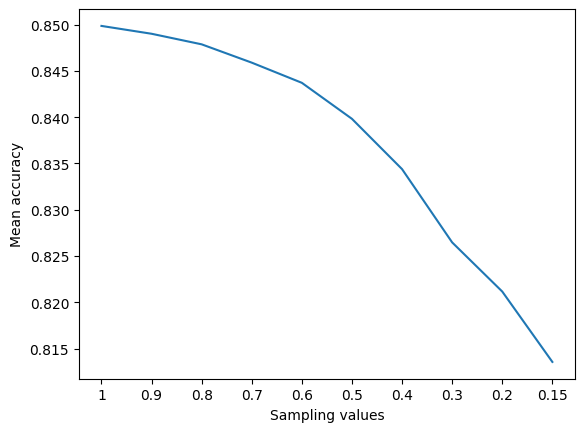

In [74]:
plt.plot(sampling_values, means)
plt.xlabel('Sampling values')
plt.ylabel('Mean accuracy')